## Asignatura: Seminario Avanzado de Aprendizaje Automático 2025-2026
## **Entregable Parte 3**
#### Master en Lógica, Computación e Inteligencia Artificial
#### Profesor: Eduardo Sánchez Karhunen (fesanchez at us.es)


#### Nombre del alumno/a:

```
Manuel Enciso Martínez
```



# **Desafío: Tu Primer Clasificador con BERT**

Ahora que ya conoces los fundamentos de los modelos Transformer y las arquitecturas BERT/GPT, ha llegado el momento de aplicar ese conocimiento. Te propongo un reto abierto y creativo. Vamos a hacer algo muy parecido a lo que te podría tocar en tu primer día trabajando en una empresa de IA. Te encargan una tarea sin darte muchas pistas, y tú tienes que organizarte y sacarla adelante. No te preocupes: aquí tendrás más tiempo que en la vida real 😉. En el mundo real te darían una mañana para hacer esto. Aquí vas a tener 10 días. ¡Úsalos bien!

El objetivo no es pasarlo mal, sino que te enfrentes a un reto realista. La idea es que veas la diferencia tan grande que hay entre tener un notebook con el código ya escrito y la infinidad de dificultades que aparecen cuando tienes que montarlo tú mismo desde cero.

**Pista importante:**

La explicación de lo que haces importa casi tanto como lo que haces. En cada paso debes ir explicando:

* Qué pasos has seguido

* Dónde has buscado información

* Qué te ha costado más

* Cómo lo has solucionado

El objetivo es que seas capaz de entrenar y evaluar el modelo. Pero tanto si lo consigues como si no, en el entregable explicalo TODO (incluido los motivos por los que no has sido capaz de completarlo, las dificultades que te has encontrado, etc.).

Pero recuerda que lo más importante es lo que te lleves en tu "mochila" trabajando el notebook y eso es lo que se va a evaluar. Todo eso queda plasmado en la mítica escena de Star Wars donde el Maestro Yoda le dice a SkyWalker: **"El fracaso, el mejor maestro es"**.  

**¿Qué tienes que hacer?**

Escoge **el dataset que quieras** (siempre que sea de procesamiento del lenguaje natural) y **resuelve un problema de clasificación** con él (por ejemplo, clasificar opiniones, intenciones, temas, etc.)

Pero hay una condición:

**Tienes que usar embeddings generados por un modelo tipo BERT.**

Además no vale solo que funcione:

**Tienes que justificar las decisiones** que tomes. Piensa como si tuvieras que explicarle tu solución a tu jefe o a tu cliente.

## 🧪 **Tarea 1: ¡Tu eliges la aventura!**

Es el momento de ponerte en el lugar de un data scientist de verdad. Elige el dataset que más te guste y plantea un problema de clasificación con el.

Para ello, describe:

* Cual es el problema de clasificación que vas a resolver.

     `Predecir una puntación del 1 al 5 en función de reseñas de textos de los usuarios.`

* Qué dataset has elegido y por qué.

     `Para evitar repetir dataset de clasificación de sentimientos, que hemos visto en otras asignaturas, he tratado de buscarlo algo un poco más diferente y he encontrado en Kaggle el siguiente dataset: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews (que trata sobre reseñas de comida en Amazon, evaluadas del 1 al 5).`

## 🕵️‍♂️ **Tarea 2: Conociendo tus datos**

Antes de hacer magia con BERT, ¡hay que conocer los datos! Haz un pequeño análisis exploratorio: cuántos ejemplos hay, cómo están distribuidas las clases, qué pinta tienen los textos ...

***Tip***: No hace falta que sea un extremadamente técnico, pero intenta entender qué tienes delante.

In [1]:
import pandas as pd
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    print("Running in Google Colab. Loading half of the instances (250,000 rows) due to memory constraints.")
    csv_path = 'Reviews.csv' # Subido al google colab
    df = pd.read_csv(csv_path, encoding='utf-8', on_bad_lines="skip", nrows=10000) # Google colab se satura la RAM
    # df = pd.read_csv(csv_path, encoding='utf-8', on_bad_lines="skip", nrows=20000) # Google colab se satura la RAM

else:
    print("Running locally. Loading all instances.")
    # Local path provided by the user
    csv_path = r"C:\Users\encis\.cache\kagglehub\datasets\snap\amazon-fine-food-reviews\versions\2\Reviews.csv" # Direccion en local
    df = pd.read_csv(csv_path, encoding='utf-8', on_bad_lines="skip", nrows=10000)

# Mostramos las columnas que tiene el dataset y las primeras 5 instancias para cada una.
print("Columns:", df.columns.tolist())
print(df.head())
print(f"Loaded {len(df)} rows.")

Running in Google Colab. Loading half of the instances (250,000 rows) due to memory constraints.
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  130792

In [2]:
## Vamos a mostrar la distribución de Score (variable objetiva)
import plotly.express as px

# Cuenta la distribución de la clase objetivo
counts = df["Score"].value_counts().reset_index()
counts.columns = ["Score", "Veces"]

# Mostar mediante diagrama de barras distribución de puntuaciones
fig = px.bar(counts, x="Score", y="Veces", color="Score", text="Veces",
             title="Distribución de puntuaciones")
fig.update_traces(textposition="outside")
fig.show()



In [3]:
counts["Veces"][0]/counts["Veces"].sum()

np.float64(0.6183)

Bastante desbalanceadas las clases. Siendo la clase mayoritaria la $5$, con más del $60$% de las muestras totales.

In [4]:
## Vamos a mostrar la distribución de longitud Text (variable predictiva)

# Nos quedamos con la columna de textp
text_df = df['Text'].str.split().str.len()
text_mean = text_df.mean() # Media
text_var = text_df.var() # Varianza
text_max = text_df.max() # Máximo
text_min = text_df.min() # Mínimo

print(f"Longitud media + varianza de text: {text_mean:.2f}+{text_var:.2f}")
print(f"Longitud máxima de text: {text_max}")
print(f"Longitud mínima de text: {text_min}")

Longitud media + varianza de text: 76.23+5344.56
Longitud máxima de text: 1513
Longitud mínima de text: 10


Observamos que tenemos una media reducida, pero una varianza bastante elevada (muchas reseñas con poco texto y algunas con mucho).

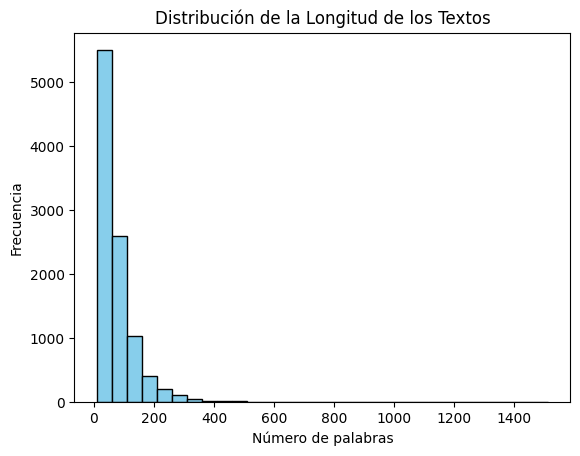

In [5]:
import matplotlib.pyplot as plt

# Crear el histograma
text_df.plot(kind='hist', bins=30, edgecolor='black', color='skyblue')

# Añadir títulos y etiquetas
plt.title('Distribución de la Longitud de los Textos')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()


Alta concentración en textos pequeños, y algunas reseñas con muchísimo texto.

## ✂️ **Tarea 3: ¡Divide y vencerás!**

Separa los datos en train y test. Por ahora, olvídate de tensores y frameworks raros: con `numpy` vas más rápido y te evitas líos.

* ¿El dataset ya venía dividido? Usa esa división.
* En caso contrario, usa un 80% para train y un 20% para test.

Quieres que las **clases estén bien representadas** en ambos conjuntos, así que utiliza el argumento `stratify = y` de scikit-learn.

In [6]:
# Tu código y explicación aquí
# Antes de dividir el dataset, vamos a quedarnos tan solo con las columnas que nos interesan para la clasificación (Score y Text)
df = df[['Score','Text']]
df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


Comprobamos si tenemos instancias vacias (importante sobretodo en el Score).

In [7]:
df.isna().sum()

,0
Score,0
Text,0


Dividimos entre variable 'X' (texto usado para la clasificación) y varibale 'y' (atributo objetivo Score)

In [8]:
import pandas as pd

# Aseguramos que 'Score' y 'Text' no tengan valores nulos y luego extraemos X e y
df_cleaned = df.dropna(subset=['Score', 'Text'])
X = df_cleaned['Text']
y = df_cleaned['Score']

print(f"Dimensiones de X después de la limpieza: {X.shape}")
print(f"Dimensiones de y después de la limpieza: {y.shape}")

Dimensiones de X después de la limpieza: (10000,)
Dimensiones de y después de la limpieza: (10000,)


In [9]:
# Ahora si vamos a dividir el conjunto para train y test en 80% y 20% respectivamente
from sklearn.model_selection import train_test_split
import numpy as np

# Dividimos mediante train_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)

print("Número de instancias del conjunto de entrenamiento:\n",np.shape(y_train))
print("Número de instancias del conjunto de test:\n",np.shape(y_test))

Número de instancias del conjunto de entrenamiento:
 (8000,)
Número de instancias del conjunto de test:
 (2000,)


## 🧱 **Tarea 4: Es hora de construir tu propio Transformer**

Debes crear tu propio modelo basado en BERT. No tienes que inventar la rueda. Vamos a combinar 3 bloques:
  * `BertTokenizer.from_pretrained(...)`
  * `TFBertModel.from_pretrained(...)`
  * Una **cabeza de clasificación** encima.

**Tips**:  
  - Tendrás que tomar decisiones sobre la longitud máxima de las secuencias.   
  - Tienes que tokenizar los textos usando usando padding y truncado.  
  - `TFBertModel` no predice clases por sí mismo. Te da los emebeddings, y tú decides que hacer con ellos.  
  - Usaremos el embedding del token `[CLS]` como resumen de toda la frase.  
  - El encadenamiento de los tres bloques puedes realizarlo con la API funcional de Tensorflow.

In [10]:
# Tu código y explicación aquí

num_labels = len(df['Score'].unique())   # Número de etiquetas

print(f"Número de clases: {num_labels}")

Número de clases: 5


Importamos modelo BERT para la clasificación, versión en inglés.

In [11]:
from transformers import BertTokenizer, BertModel
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", use_fast=True)
model_base = BertModel.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Definimos el encoder

In [12]:
import torch

MAX_LEN = 128 # Reducimos la longitud máxima para ahorrar RAM y nuestro dataset tiene textos reducidos

def encode_batch(texts):
    return tokenizer(
        list(texts),
        padding="max_length", # Rellenar con pad hasta longitud max
        truncation=True, # Cortar frases más largas a longitud max
        max_length=MAX_LEN,
        return_tensors="pt"
    )

# Pasamos por el encoder el conjunto de textos de entrenamiento y validacion
train_enc = encode_batch(X_train)
val_enc   = encode_batch(X_test)

# Transformamos a vectores de pytorch y ajustamos los labels para que sean 0-indexed
y_train = torch.tensor(np.array(y_train) - 1, dtype=torch.long)# Restamos 1 para que los scores 1-5 se conviertan en 0-4
y_test   = torch.tensor(np.array(y_test)  - 1, dtype=torch.long)# Restamos 1 para que los scores 1-5 se conviertan en 0-4


Generamos los batch para entrenamiento/validación

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    train_enc["input_ids"],
    train_enc["attention_mask"],
    train_enc["token_type_ids"],
    y_train
)

val_dataset = TensorDataset(
    val_enc["input_ids"],
    val_enc["attention_mask"],
    val_enc["token_type_ids"],
    y_test
)

BATCH_SIZE = 16   # Tamaño del batch (textos sucesivos hasta actualización de pesos)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

Modelo de clasificación

In [14]:
import torch
import torch.nn as nn
from transformers import BertModel

class BertClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name) # Nuestro modelo BERT
        self.dropout = nn.Dropout(dropout) # DROPOUT para regularización (evitar sobreajuste)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels) # Modelo de clasificación

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        pooled = outputs.pooler_output
        x = self.dropout(pooled)
        logits = self.classifier(x)
        return logits

model = BertClassifier("bert-base-uncased", num_labels) #Modelo BERT listo para entrenar

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 🏋️‍♀️ **Tarea 5: Entrenamiento**

¡Llegó la hora de poner a sudar a tu modelo!
Aquí empieza el verdadero drama del Deep Learning: decidir cuántas muestras va a ver de golpe `batch_size`, con qué rapidez va a aprender `learning_rate`, y cuándo parar para no liarla `early_stopping`.

En esta sección tienes que:

* Elegir bien los hiperparámetros.
    - Sí, vas a tener que probar.
    - Y sí, probablemente al principio no funcione tan bien como esperabas.

* Controlar el sobreajuste. Si ves que tu modelo acierta todo en entrenamiento pero falla en validación... mal asunto. Prueba a:

    - Usar Dropout

    - Subir el batch_size

    - Afinar el learning_rate



```
Proceso que hemos seguido:
```
Vamos a usar el conjunto de test para mostrar el rendimiento obtenido después de cada época entrenada sobre el conjunto de entrenamiento.

Al final no he implementado 'early_stopping' debido a que el número de épocas que he usado en el entrenamiento es bastante reducido y no lo he considerado necesario.

Para un mejor rendimiento sobre el conjunto de test, podría haber aplicado los siguientes cambios:
* Aumentar el número de datos en entrenamiento.
* Reducir la tasa de aprendizaje y aumentar el número de épocas.
* Implementar early_stopping con un valor de pacience razonable.




Epoch 1/5 | Train Acc: 0.5487 | Test Acc:  0.6630
Epoch 2/5 | Train Acc: 0.6683 | Test Acc:  0.7065
Epoch 3/5 | Train Acc: 0.7488 | Test Acc:  0.6685
Epoch 4/5 | Train Acc: 0.8237 | Test Acc:  0.7095
Epoch 5/5 | Train Acc: 0.8655 | Test Acc:  0.7130


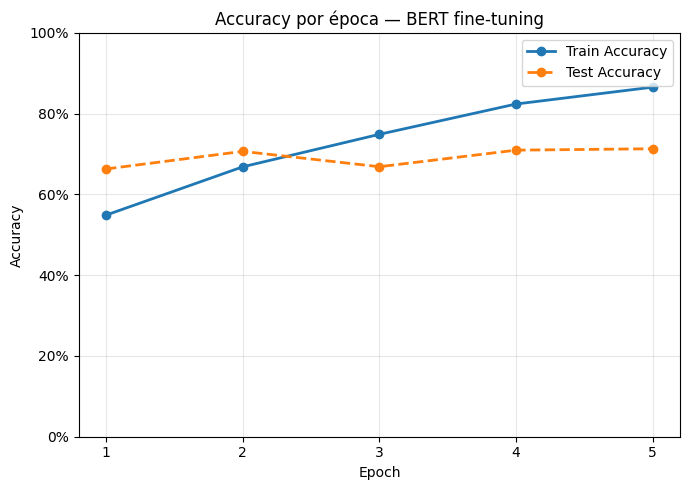

In [15]:
# Tu código y explicación aquí

import torch.nn as nn
import matplotlib.ticker as mticker
from transformers import get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight

# Definimos el número de épocas en 5 (para fine-tuning es suficiente) y tasa de aprendizaje
EPOCHS = 5
LR     = 2e-5

# Usar gpu para entrenamiento si se puede
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# y_train en array de numpy
y_train_np = y_train.numpy()

# IMPORTANTE!! Para nuestro dataset entrenar con balanceamiento entre clases
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(5),
    y=y_train_np
)

# Convierte a tensor float en el mismo device que el modelo
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Funión de pérdida entropía cruzada con pesos por balanceamiento y optimizador Adam
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Para guardar histórico de métricas por épocas
history = {
    "train_acc": [],
    "val_acc":   []
}

# Bucle de entrenamiento y evaluación sobre X_test
for epoch in range(EPOCHS):

    # Indicar que el modelo esta en fase de entrenamiento
    model.train()
    correct_train, total_train = 0, 0

    for batch in train_loader:
        input_ids, attention_mask, token_type_ids, labels = [
            b.to(device) for b in batch
        ]

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(logits, dim=-1)
        correct_train += (preds == labels).sum().item()
        total_train   += labels.size(0)

    train_acc = correct_train / total_train
    history["train_acc"].append(train_acc)

    # Indicar que el modelo esta en fase de validación (desactivamos dropout y no modificar pesos)
    model.eval()
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, token_type_ids, labels = [
                b.to(device) for b in batch
            ]
            logits = model(input_ids, attention_mask, token_type_ids)
            preds  = torch.argmax(logits, dim=-1)
            correct_val += (preds == labels).sum().item()
            total_val   += labels.size(0)

    val_acc = correct_val / total_val
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc:  {val_acc:.4f}"
    )

# Mostramos graficamente el porcentaje de aciertos del historial para X_train/X_test
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_acc"], "o-",  lw=2, label="Train Accuracy")
plt.plot(epochs, history["val_acc"],   "o--", lw=2, label="Test Accuracy")

# Opcional: mostrar en porcentaje
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.title("Accuracy por época — BERT fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

El accuracy sobre el conjunto de entrenamiento siempre sube (como era de esperar) y el de test varía en mayor medida, aunque consigue unos valores aceptables.

Vamos a comprobar en la siguiente sección si hemos logrado que nuestro modelo aprenda a puntuar reseñas de comidas en inglés.

## 🧐 Tarea 6: Evaluación

Momento de la verdad!
Tu modelo ha entrenado, ha aprendido (esperemos), y ahora toca ver cómo se comporta con datos que no ha visto nunca.

En esta parte:

* Evalúa el modelo sobre el conjunto de test.

* Representa las curvas de entrenamiento y validación (accuracy y loss) para ver si ha habido sobreajuste, infrajuste… o magia pura.

* Comenta brevemente los resultados: ¿ha aprendido bien? ¿hay alguna clase que le cueste más?

Vamos a evaluar el modelo sobre unas nuevas reseñas que hemos escrito.

Ya en la fase de entrenamiento hemos mostrado el rendimiento sobre el conjunto de test. Este porcentaje nos da una idea del rendimiento y además el resultado es objetivo porque no se ha usado para detener el entrenamiento ni ajustar ningún hiperparametro.

In [16]:
# Tu código y explicación aquí

def BERT_predict(x_new):
  model.eval()  # Modo de predicción

  # Tokenizar la nueva reseña
  enc = tokenizer(
      [x_new],
      padding="max_length",
      truncation=True,
      max_length=MAX_LEN,
      return_tensors="pt"
  )

  # Mover tensores al mismo dispositivo
  input_ids      = enc["input_ids"].to(device)
  attention_mask = enc["attention_mask"].to(device)
  token_type_ids = enc["token_type_ids"].to(device)

  # Inferencia de la reseña para calcular probabilidades y predicción (clase con probabilidad)
  with torch.no_grad():
      logits = model(input_ids, attention_mask, token_type_ids)
      probs  = torch.softmax(logits, dim=-1)
      pred   = torch.argmax(probs, dim=-1).item()

  # Como la predicción viene dada entre [0,4] transformamos mediante +1 al intervalo [1,5]
  score_predicho    = pred + 1
  confianza         = probs[0][pred].item()

  print(f"Reseña:           '{x_new}'")
  print(f"Score predicho:   {score_predicho} / 5")
  print(f"Confianza:        {confianza:.2%}")
  print(f"Probs por clase:  {[f'Score {i+1}: {p:.2%}' for i, p in enumerate(probs[0].tolist())]}")

In [17]:
BERT_predict("What a delicious meal!")

Reseña:           'What a delicious meal!'
Score predicho:   5 / 5
Confianza:        95.05%
Probs por clase:  ['Score 1: 0.35%', 'Score 2: 0.13%', 'Score 3: 0.39%', 'Score 4: 4.07%', 'Score 5: 95.05%']


Efectivamente, es un reseña muy positiva y asigna el valor de mayor puntuación y con mucha confianza.

In [18]:
BERT_predict("It's fine, but there are better ones.")

Reseña:           'It's fine, but there are better ones.'
Score predicho:   3 / 5
Confianza:        97.28%
Probs por clase:  ['Score 1: 0.21%', 'Score 2: 0.68%', 'Score 3: 97.28%', 'Score 4: 1.51%', 'Score 5: 0.32%']


También acierta que es una reseña de valor medio, asignando neutralidad en la puntuación. Destacar que las dos clases siguientes que presentan una mayor probabilidad además corresponden con el valor '2' y '4' que podrían ser también los siguientes valores más adecuados.

In [19]:
BERT_predict("The worst thing I've tasted in a long time")

Reseña:           'The worst thing I've tasted in a long time'
Score predicho:   1 / 5
Confianza:        93.18%
Probs por clase:  ['Score 1: 93.18%', 'Score 2: 0.59%', 'Score 3: 0.78%', 'Score 4: 1.23%', 'Score 5: 4.23%']


Claramente es una mala reseña y la clasifica con la peor puntuación. En esta cosa la segunda clase con mayor probabilidad es la '5', lo cual es un poco contradictorio aunque se puede deber al desbalance que presenta el dataset (aunque hayamos entrenado con balanceo entre clases), podríamos seguir analizando todo si tuvieramos más tiempo para sacar matriz de confusión y obtener un mejor análisis.

## ✨ Tarea 7: Reflexión final

* Si has llegado hasta aquí: Enhorabuena!!!. Recuerda explicar todo lo que ha ido pasando por el camino.  

* Si no, describe en detalle hasta donde has llegado y qué está haciendo que no hayas conseguido completar el entregable. Y sobretodo ...., cómo lo vas a arreglar para que cuando te encarguen una tarea real se este tipo, la superes con éxito.

```
Conclusión final:
```
Hemos observamos como al aplicarle fine-tuning al modelo BERT por defecto, para nuestra nueva tarea de clasificación de reseñas, el modelo logra con unas pocas épocas un gran rendimiento. Esto se debe a la potencia del modelo BERT que, mediante sus representaciones vectoriales, es capaz de capturar un valor asociados a los textos de las reseñas.

Respecto a la dificultades del trabajo. Destacar que nuestro conjunto de datos tenía dos inconvenientes principales:
* **Tamaño del dataset:** Al tener más de 500 mil instancias, el entrenamiento saturaba la RAM (y por la elección de parámetros). Al final he considerado perder información reduciendo el número de instancias para el entrenamiento, para poder entrenar el modelo usando Google Colab. Resulta que aunque haya reducido a 10 mil instancias el tamaño del dataset, los resultados siguen siendo aceptables para la tarea.
* **Desbalanceo entre clases:** Al presentar la clasificación número '5' una mayor frecuencia respecto del resto de clases, el entrenamiento requería de balancear la pérdida para que no aprendiese solo a predecir la clase '5' de manera constante (error que pase por alto en mi primer entrenamiento).

Al final hemos logrado entrenar nuestro modelo BERT para la tarea en cuestión. Hemos comprobado su eficacia al evaluar reseñas fictícias y observar que logra predecir, con una alta confianza, el resultado esperado para cada una de ellas.





---